# Best Neighborhood in Pittsburgh

## Team Name: Lions

### Introduction

We have three datasets provided by WPRDC: Arrest Rate Dataset, Playground Dataset, and Community Engagement Dataset. We have to analyze all the datasets containing information about the neighborhood, and come up with a metric to determine which neighborhood is the best one. In order for us to determine which neighborhood is the best, we tried to think of necessities in a neighborhood that attracts people. For example, people care about the liveliness of a neighborhood, safety, and a place where their children can play. Based on all of the needs, we would determine which neighborhood is mostly likely to satisfy people’s needs.

### Metric

For our metric, community engagement, we assigned numeric values to three factors for each neighbourhood (safety, recreation access, and community activity); we then created a weighted point system that took into account the number of playgrounds and community centres as well as the number of arrests in the area to determine which neighbourhood had the highest combined score.

#### Arrest Rate Dataset

The Pittsburgh Arrest Dataset from WPRDC is used to measure the Safety of Neighborhoods, by totaling arrest counts per Neighborhood. Arrest Numbers are then merged with Population data to normalize across Neighborhoods with different populations. For comparison of arrest rates, neighborhoods with populations less than 1,000 residents are removed, to eliminate skewed arrest rates due to low populations. Arrest rates are calculated as Arrest Numbers divided by 1,000 Residents. Arrest rates contribute to Safety Score, the higher the number of arrests the lower the Safety Score.


Winner: Central Northside

Loser: Central Business District

#### Community Center Attendance

Importing pandas and matplotlib allows me to load and clean data tables. It lets me make charts. After importing, I load my Community Engagement dataset. I print the first 10 rows of the dataset The second picture shows that I am grouping attendance data by community center name. It sums all attendance counts per center and it sort centers from highest to lowest attendance. First, I am creating a bar chart of attendance by center. Later, I add title + axis labels. I am just rotatating center names so they are readable. Finally, it displays the chart. The results show that the community with the highest attendance is Brookline Community Center. The one with the lowest attendance is Arlington Community Center.

Winner: Brookline

Loser: Arlington

#### Playground Dataset

First, we importing pandas and matlibplot because it helps clean data and make charts. Second, I loading the Playgrounds file. Then, I printing the first 10 rows to test things out. If any playground has no neighborhood listed, I replace it with "Unknown". This makes the data clean and usable. The code where I use value_counts() counts how many playgrounds each neighborhood has. The sort_values(ascending=False) basically shows most playgrounds at the top. Lastly, prints shows the result. The second image shows how I created the bar chart like the Community Engagement Dataset. The results show the neighborhood with the highest playground is Squirrel Hill South. There’s a lot of neighborhoods that have the same amount of playgrounds.

### The Best Neighborhood

After combing all three datasets to the best of out ability the best neighborhood based on our metric is Central Northside.

### Conclusion

By using a combination of combined scoring methods, we determined that Greenfield is Pittsburgh’s best neighborhood based on our scoring method. This scoring method allows for comparing neighborhoods on several levels of community life through conversion of the scores into a weighted system of points based on the respective datasets. Greenfield has proven to be a good neighborhood across the board for each of those datasets. Although this analysis will vary based upon the datasets used and how they were weighted, it is an excellent representation of how different areas support each of these three factors (safety, activity, and availability of public resources) in our analysis. Therefore, Greenfield has the highest score and, therefore, takes the overall. 

### The Data

We start by importing pandas, and then the following data:

The police arrest rate data

The total population of each neighborhood data

The daily community center attendance data

The number of playgrounds in each neighborhood data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

arrest_csv = "https://data.wprdc.org/datastore/dump/e03a89dd-134a-4ee8-a2bd-62c40aeebc6f"
arrests = pd.read_csv(arrest_csv)

pop_csv ="https://data.wprdc.org/dataset/5b18c198-474c-4723-b735-cc5220ad43cc/resource/82f29015-6905-4b1c-8300-afe9bb2231b3/download/total-population.csv"
population = pd.read_csv(pop_csv)

play_csv = "https://data.wprdc.org/datastore/dump/47350364-44a8-4d15-b6e0-5f79ddff9367"
playgrounds = pd.read_csv(play_csv)

community_csv = "https://data.wprdc.org/datastore/dump/b7cb30c8-b179-43ff-8655-f24880b0f578" 
attendance = pd.read_csv(community_csv) 

In [4]:
arrests = arrests.rename(columns={'INCIDENTNEIGHBORHOOD': 'Neighborhood'})

population = population.rename(columns={'Estimate; Total': 'Population'})
population = population.drop(columns = ['Margin of Error; Total'], errors = 'ignore')

### Arrest Rate Data Analysis

Now we are going to count the total arrests by neighborhood.

In [5]:
arrest_counts = arrests.groupby('Neighborhood').size().reset_index(name='Total_Arrests')
print(arrest_counts)

           Neighborhood  Total_Arrests
0      Allegheny Center           1244
1        Allegheny West            130
2             Allentown            947
3             Arlington            312
4     Arlington Heights            155
..                  ...            ...
93  Upper Lawrenceville            189
94             West End            290
95         West Oakland            325
96             Westwood            226
97              Windgap            124

[98 rows x 2 columns]


Now we merge arrest and population data, filter out small neighborhoods, calculate arrests per 1,000 residents, and show the top 5 neighborhoods by that rate.

In [6]:
arrest_rate = arrest_counts.merge(population, on='Neighborhood', how='left')

arrest_rate = arrest_rate[arrest_rate['Population'] >= 1000]


arrest_rate['Arrests_Per_1k'] = (arrest_rate['Total_Arrests'] / arrest_rate['Population']) * 1000

arrest_rate.sort_values(by=['Arrests_Per_1k'], ascending=True).head(5)


,Neighborhood,Total_Arrests,Id,Population,Arrests_Per_1k
19,Central Northside,23,19.0,2892.0,7.952974
82,Squirrel Hill North,290,77.0,11336.0,25.582216
88,Swisshelm Park,43,83.0,1345.0,31.970260
72,Regent Square,37,67.0,1033.0,35.818006
85,Stanton Heights,223,80.0,4761.0,46.838899


This will plot the top 10 neighborhoods with the lowest arrest rates. 

<Axes: title={'center': '10 Neighborhoods with Lowest Arrests per 1,000 Residents'}, xlabel='Neighborhood'>

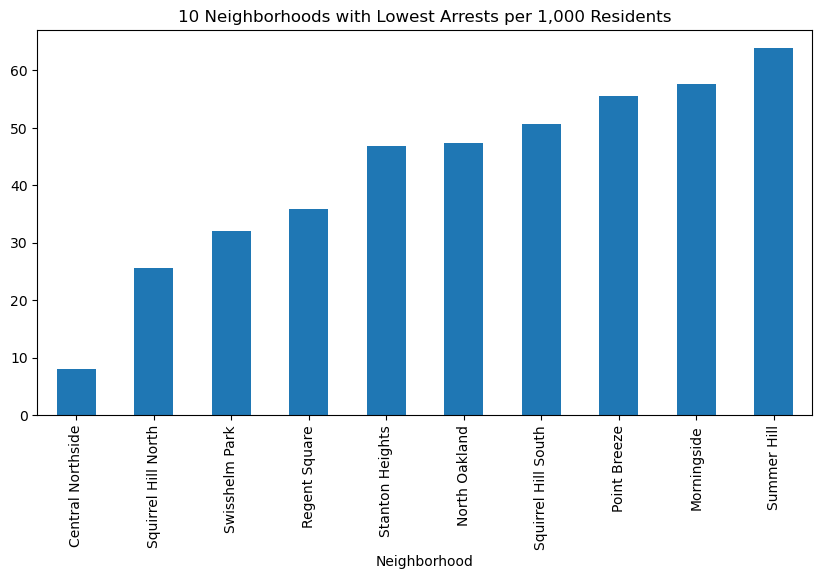

In [7]:
lowest_arrests = arrest_rate.sort_values(by='Arrests_Per_1k', ascending=True).head(10)

lowest_arrests.plot(kind='bar', x='Neighborhood', y='Arrests_Per_1k',legend=False, figsize=(10,5), title='10 Neighborhoods with Lowest Arrests per 1,000 Residents')

#### Winner: Central Northside
#### Loser: Central Business District

In [8]:
topNeighborhoods = arrest_rate.sort_values(by=['Arrests_Per_1k'], ascending=True) .head(20) 

### Playground Data

In [9]:
# Fill missing neighborhood names
playgrounds["neighborhood"] = playgrounds["neighborhood"].fillna("Unknown")

# Optionally filter out retired playgrounds
if "retired" in playgrounds.columns:
    playgrounds = playgrounds[playgrounds["retired"] != "Yes"]

# Keep only columns we need
playgrounds = playgrounds[["neighborhood"]]

In [10]:
playgrounds = playgrounds.rename(columns={'neighborhood': 'Neighborhood'})
counts_by_neighborhood = playgrounds["Neighborhood"].value_counts().sort_values(ascending=False)
print(counts_by_neighborhood)

Neighborhood
Squirrel Hill South    8
Beechview              5
South Side Slopes      5
Highland Park          4
Sheraden               4
                      ..
West End               1
Polish Hill            1
Point Breeze North     1
Squirrel Hill North    1
East Allegheny         1
Name: count, Length: 68, dtype: int64


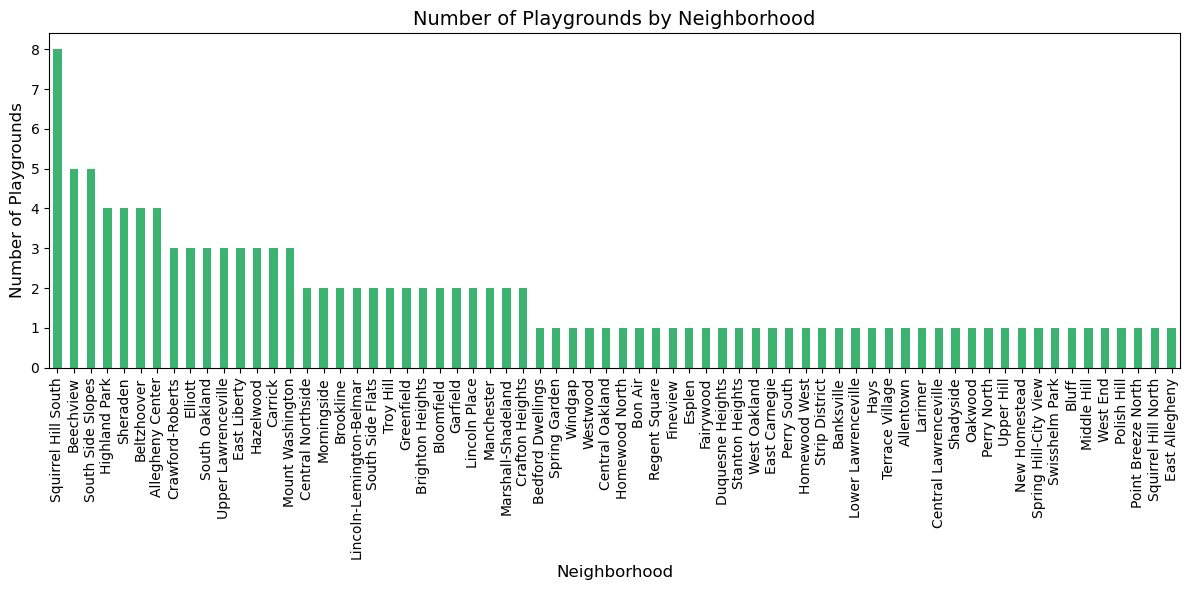

In [11]:
plt.figure(figsize=(12,6))
counts_by_neighborhood.plot(kind='bar', color='mediumseagreen')
plt.title("Number of Playgrounds by Neighborhood", fontsize=14)
plt.xlabel("Neighborhood", fontsize=12)
plt.ylabel("Number of Playgrounds", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Winner: Squirrel Hill South

### Community Engagement

In [12]:
# Fill missing names
attendance["center_name"] = attendance["center_name"].fillna("Unknown")

# Filter only Community Centers (based on name)
attendance = attendance[attendance["center_name"].str.contains("Community Center")]

# Keep only relevant columns
attendance = attendance[["center_name", "attendance_count"]]
attendance.head(10)

,center_name,attendance_count
0,Arlington Community Center,18
1,Brookline Community Center,19
2,Ormsby Community Center,9
3,Paulson Community Center,1
4,Phillips Community Center,17
5,Warrington Community Center,32
6,Magee Community Center,18
7,West Penn Community Center,59
8,Brookline Community Center,30
9,Arlington Community Center,20


In [13]:
# Group by center_name and sum attendance
attendance_by_center = attendance.groupby("center_name")["attendance_count"].sum().sort_values(ascending=False)

# Display the result
attendance_by_center

center_name
Brookline Community Center     376481
West Penn Community Center     264384
Phillips Community Center      249523
Ammon Community Center         176613
Warrington Community Center    127179
Ormsby Community Center        104574
Magee Community Center         103933
Jefferson Community Center      75850
Paulson Community Center        73705
Arlington Community Center      73109
Name: attendance_count, dtype: int64

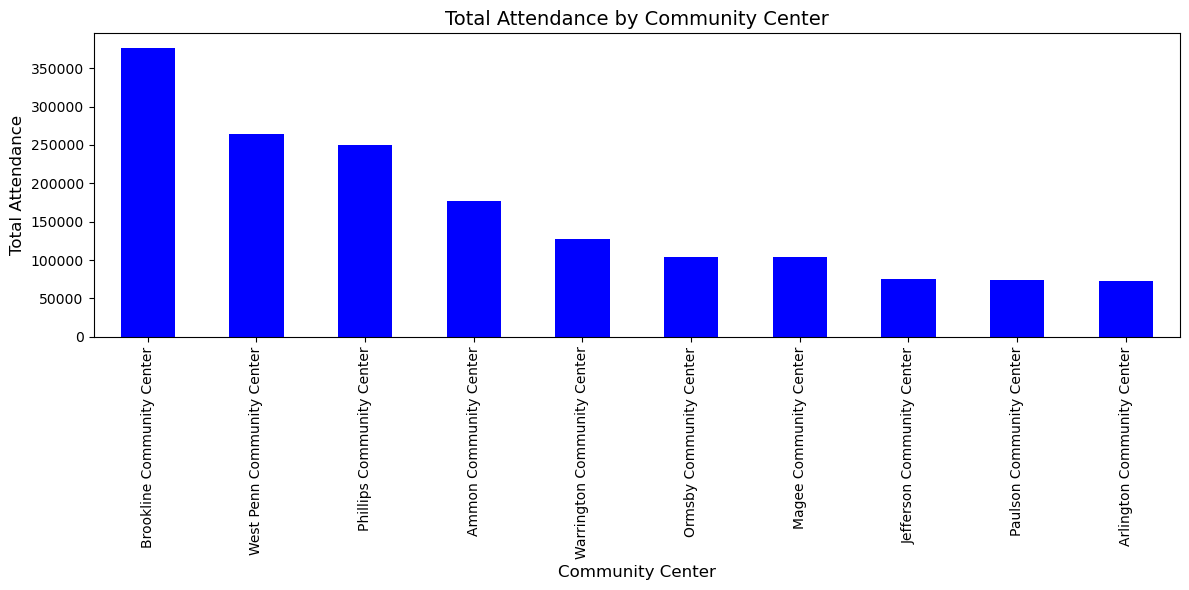

In [14]:
plt.figure(figsize=(12,6))
attendance_by_center.plot(kind='bar', color='blue')
plt.title("Total Attendance by Community Center", fontsize=14)
plt.xlabel("Community Center", fontsize=12)
plt.ylabel("Total Attendance", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Winner: Brookline 
#### Loser: Arlington

Now we manually map the community center to their neighborhoods and find the average attendance.  

In [15]:
center_to_hood = {'Brookline Community Center' : 'Brookline', 'West Penn Community Center' : 'Polish Hill', 'Phillips Community Center' : 'Carrick', 'Ammon Community Center' : 'Hill District', 'Warrington Community Center' : 'Beltzhoover', 'Ormsby Community Center' : 'South Side Flats', 'Magee Community Center' : 'Greenfield', 'Jefferson Community Center' : 'Central North Side', 'Paulson Community Center' : 'Lincoln-Lemington-Belmar', 'Arlington Community Center' : 'Arlington'}
attendance['Neighborhood'] = attendance['center_name'].map(center_to_hood)
attendance_avg = (attendance.groupby("Neighborhood")["attendance_count"].mean().reset_index(name="Avg_Attendance"))

Summarize the data that hasn't been summarized yet.

In [16]:
pop = population[['Neighborhood', 'Population']]
play_counts = playgrounds.groupby('Neighborhood').size().reset_index(name='Playgrounds')

summary = (arrest_counts.merge(pop, on='Neighborhood', how='inner').merge(play_counts, on='Neighborhood', how='left').merge(attendance_avg, on='Neighborhood', how='left'))

summary['Total_Rate'] = (summary['Total_Arrests'] / summary['Population']) * 1000

summary.set_index('Neighborhood', inplace=True)
summary = summary[['Population', 'Total_Arrests', 'Total_Rate', 'Playgrounds', 'Avg_Attendance']]
#summary.set_index('Neighborhood', inplace=True)

summary = summary.sort_values('Total_Rate')

print(summary.head(10))

                     Population  Total_Arrests  Total_Rate  Playgrounds  \
Neighborhood                                                              
Central Northside        2892.0             23    7.952974          2.0   
Squirrel Hill North     11336.0            290   25.582216          1.0   
Swisshelm Park           1345.0             43   31.970260          1.0   
Regent Square            1033.0             37   35.818006          1.0   
New Homestead             973.0             39   40.082220          1.0   
Stanton Heights          4761.0            223   46.838899          1.0   
North Oakland            9602.0            455   47.385961          NaN   
Squirrel Hill South     16042.0            812   50.617130          8.0   
Point Breeze             5414.0            301   55.596601          NaN   
Morningside              3262.0            188   57.633354          2.0   

                     Avg_Attendance  
Neighborhood                         
Central Northside      

### Visual Representation

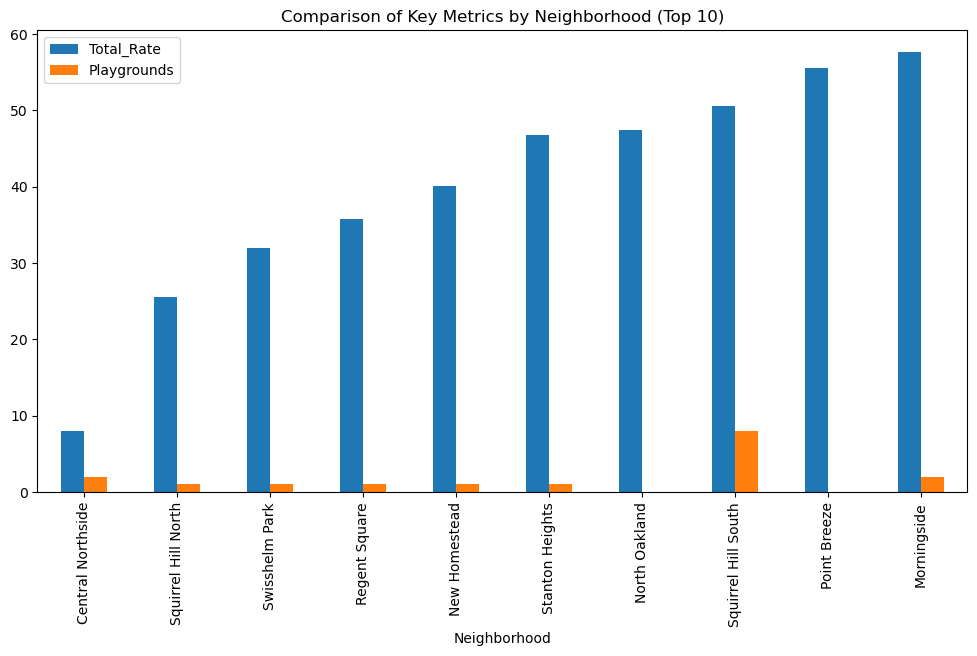

In [17]:
summary[['Total_Rate', 'Playgrounds']].head(10).plot(kind='bar',figsize=(12, 6), title='Comparison of Key Metrics by Neighborhood (Top 10)',)

plt.show()

### Scoring System

Use the summary table I have already created above 

In [18]:
scores = summary.reset_index()[['Neighborhood', 'Total_Rate', 'Playgrounds', 'Avg_Attendance']].copy()

Creating a score system for each dataset, weight the scoring, and remove every neighborhood with 0 attendance to even out the scoring.

In [19]:
scores = scores[scores['Avg_Attendance'] > 0]
scores['Playgrounds'] = scores['Playgrounds'].fillna(0)

scores['crime_score'] = -scores['Total_Rate']         
scores['playground_score'] = scores['Playgrounds']    
scores['attendance_score'] = scores['Avg_Attendance']  

weights = {
    'crime_score': 3,
    'playground_score': 2,
    'attendance_score': 1
}

Now we find the final score and sort the neighborhoods.

In [22]:
scores['total_score'] = (
    scores['crime_score'] * weights['crime_score'] +
    scores['playground_score'] * weights['playground_score'] +
    scores['attendance_score'] * weights['attendance_score']
)

ranked = scores.sort_values('total_score', ascending=False)
ranked.head(20)

,Neighborhood,Total_Rate,Playgrounds,Avg_Attendance,crime_score,playground_score,attendance_score,total_score
14,Greenfield,69.830949,2.0,30.978539,-69.830949,2.0,30.978539,-174.514308
27,Brookline,105.623100,2.0,98.118582,-105.623100,2.0,98.118582,-214.750719
33,Polish Hill,124.718257,1.0,67.341824,-124.718257,1.0,67.341824,-304.812947
41,Arlington,168.466523,0.0,32.843217,-168.466523,0.0,32.843217,-472.556352
49,Carrick,232.365145,3.0,68.644567,-232.365145,3.0,68.644567,-622.450869
56,Lincoln-Lemington-Belmar,274.873865,2.0,25.078258,-274.873865,2.0,25.078258,-795.543336
59,Beltzhoover,291.421857,4.0,38.574158,-291.421857,4.0,38.574158,-827.691412
74,South Side Flats,555.785124,2.0,29.767720,-555.785124,2.0,29.767720,-1633.587652


### Visual Representation

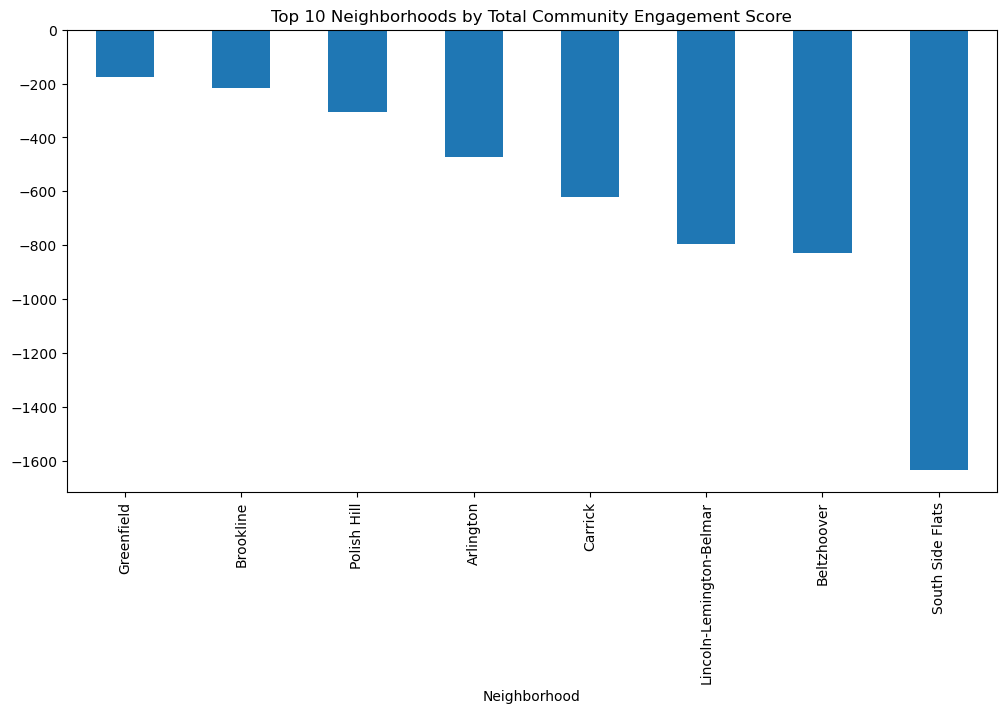

In [21]:
ranked = scores.sort_values('total_score', ascending=False)
graph = ranked.head(25).plot.bar(x='Neighborhood', y='total_score', figsize=(12, 6), legend=False, title='Top 10 Neighborhoods by Total Community Engagement Score')
plt.show()

#### Winner: Central Northside